# Libraries

In [1]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from pyxlsb import open_workbook
import warnings

warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})

SEED = 42
np.random.seed(SEED)

# Data

In [2]:
DATA_PATH = os.path.abspath(os.path.join(os.path.dirname("__file__"), "..", "data/javelin101.xlsb"))
if os.path.exists(DATA_PATH) is False:
    print("File not found: {}".format(DATA_PATH))
    
CACHE = os.path.abspath(os.path.join(os.path.dirname("__file__"), "..", "cache"))

In [3]:
def read_sheet(sheet, wide=False):
    """Read one sheet of the .xlsb. Row 0 = table title, row 1 = header."""
    f = f"{CACHE}/{sheet}.pkl"
    if os.path.exists(f):
        return pd.read_pickle(f)
    with open_workbook(DATA_PATH) as wb, wb.get_sheet(sheet) as sh:
        rows = [[c.v for c in r] for r in sh.rows()]
    hdr = rows[1]; n = len(hdr)
    body = [(r + [None] * n)[:n] for r in rows[2:] if r and r[0] is not None]
    df = pd.DataFrame(body, columns=hdr)
    if wide:   # genes x patients tables
        df = df.set_index(hdr[0]).apply(pd.to_numeric, errors="coerce")
    else:
        df = df.dropna(how="all")
    df.to_pickle(f)
    return df

def by_id(df, key):
    d = df.rename(columns={key: "id"}).drop_duplicates("id").set_index("id")
    return d.apply(pd.to_numeric, errors="coerce")

clin_raw = read_sheet("S11_Clinical_data")
cd8      = by_id(read_sheet("S12_CD8_IHC_data"), "ID")
imm      = by_id(read_sheet("S14_ImmuneNet_decon_data"), "row_id")
path     = by_id(read_sheet("S16_Pathway_scores"), "row_id")
wes      = by_id(read_sheet("S18_WES_summary_stats"), "ID")
math_    = by_id(read_sheet("S19_MATH_scores"), "ANONID")
fcgr_raw = read_sheet("S20_FCGR_mutation_data").drop_duplicates("ID").set_index("ID")
expr     = read_sheet("S13_Gene_expression_TPM", wide=True)      # log2 TPM, genes x patients
mut      = read_sheet("S21_Gene_mutation_status", wide=True)     # 0/1, genes x patients
print("clinical", clin_raw.shape, "| CD8", cd8.shape, "| immune", imm.shape, "| pathways", path.shape,
      "| WES", wes.shape, "| expr", expr.shape, "| mut", mut.shape)

clinical (886, 8) | CD8 (841, 6) | immune (727, 22) | pathways (726, 58) | WES (841, 3) | expr (22955, 726) | mut (18243, 738)


# 1. Clinical table

In [4]:
clin = clin_raw.rename(columns={"ID": "id"}).copy()
clin = clin[clin.TRT01P.isin(["Avelumab+Axitinib", "Sunitinib"])]
for c in ["PFS_P", "PFS_P_CNSR", "AGE"]:
    clin[c] = pd.to_numeric(clin[c], errors="coerce")
clin = clin.dropna(subset=["PFS_P", "PFS_P_CNSR"]).drop_duplicates("id").set_index("id")

clin["time"]  = clin.PFS_P                         # months
clin["event"] = (1 - clin.PFS_P_CNSR).astype(int)  # 1 = progression/death, 0 = censored
clin["T"]     = (clin.TRT01P == "Avelumab+Axitinib").astype(int)   # treatment indicator
print(clin.groupby("TRT01P").agg(n=("time", "size"), events=("event", "sum"), median_time_observed=("time", "median")))

                     n  events  median_time_observed
TRT01P                                              
Avelumab+Axitinib  441     188              7.096509
Sunitinib          444     234              6.488706


# 2. Feature matrix

Joins everything on patient ID: age, sex, PD-L1, TCGA cluster, CD8 IHC, immune deconvolution, pathway scores, TMB, MATH, FCGR genotype, RCC driver mutations and curated immune/angiogenesis genes

Restricts to patients with RNA-seq, drops features that are mostly missing or constant, and median-imputes the rest

In [5]:
RCC_MUT = ["VHL", "PBRM1", "BAP1", "SETD2", "KDM5C", "TP53", "PTEN", "MTOR", "ARID1A", "KMT2C", "KMT2D", "PIK3CA", "NF2", "TERT"]
EXPR_GENES = ["PDCD1", "CD274", "CTLA4", "LAG3", "TIGIT", "HAVCR2", "CD8A", "GZMB", "PRF1", "IFNG", "CXCL9", "CXCL10",
              "FOXP3", "CD68", "CD163", "VEGFA", "KDR", "FLT1", "EPAS1", "CA9", "PDGFRB", "IL6", "TGFB1", "MKI67"]

F = pd.DataFrame(index=clin.index)
F["age"]    = clin.AGE
F["male"]   = (clin.SEX == "M").astype(float)
F["pdl1_pos"] = clin.PDL1FL.map({"Y": 1.0, "N": 0.0})            # NaN if unknown
for k in ["m1", "m2", "m3", "m4", "Other"]:
    F[f"tcga_{k}"] = (clin.TCGA_cluster == k).astype(float)

F = F.join(cd8.add_prefix("ihc_").rename(columns=str.lower))
F = F.join(imm.add_prefix("imm_"))
F = F.join(path.add_prefix("path_"))
F = F.join(wes[["nonsyn_var_MB"]].rename(columns={"nonsyn_var_MB": "TMB"}))
F["log_TMB"] = np.log1p(F.TMB)
F = F.join(math_.rename(columns={"MATH": "MATH"}))
for g in ["FCGR2A(RS1801274)", "FCGR3A(RS396991)"]:
    d = pd.get_dummies(fcgr_raw[g].replace("NA", np.nan), prefix=g.split("(")[0]).astype(float)
    F = F.join(d)

mut_use = [g for g in RCC_MUT if g in mut.index and mut.loc[g].mean() >= 0.03]
F = F.join(mut.loc[mut_use].T.add_prefix("mut_"))
F = F.join(expr.loc[[g for g in EXPR_GENES if g in expr.index]].T.add_prefix("expr_"))

# analysis cohort = randomised patients with RNA-seq (the biomarker-evaluable population)
has_rna = clin.index.isin(expr.columns)
F = F[has_rna]; clin_c = clin[has_rna].copy()
F = F.loc[:, F.notna().mean() > 0.6]                 # drop features that are mostly missing
F = F.loc[:, F.nunique() > 1]
print("cohort:", len(F), "patients |", F.shape[1], "features | missing cells: %.1f%%" % (100 * F.isna().mean().mean()))

X = F.fillna(F.median())      # simple median imputation (documented limitation)
T = clin_c["T"].values
time_ = clin_c.time.values
event = clin_c.event.values
feat_names = list(X.columns)
print(clin_c.groupby("TRT01P").agg(n=("time", "size"), events=("event", "sum")))

cohort: 726 patients | 131 features | missing cells: 0.7%
                     n  events
TRT01P                        
Avelumab+Axitinib  354     157
Sunitinib          372     201


# 3. Average causal effect of the combination (randomised comparison)

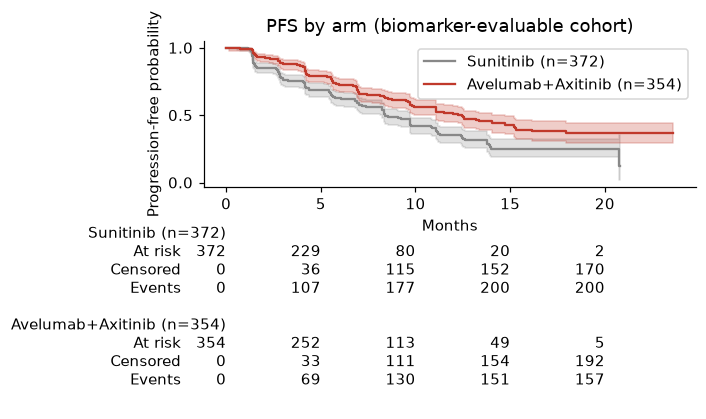

           exp(coef)  exp(coef) lower 95%  exp(coef) upper 95%      p
covariate                                                            
T              0.656                0.532                0.810  0.000
age            0.984                0.973                0.994  0.002
male           0.867                0.683                1.100  0.239


In [6]:
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.plotting import add_at_risk_counts

fig, ax = plt.subplots(figsize=(6.5, 4.2))
kms = []
for lab, col in [("Sunitinib", "#888"), ("Avelumab+Axitinib", "#c0392b")]:
    m = clin_c.TRT01P == lab
    km = KaplanMeierFitter().fit(clin_c.time[m], clin_c.event[m], label=f"{lab} (n={m.sum()})")
    km.plot_survival_function(ax=ax, color=col, ci_show=True); kms.append(km)
ax.set_xlabel("Months"); ax.set_ylabel("Progression-free probability"); ax.set_title("PFS by arm (biomarker-evaluable cohort)")
add_at_risk_counts(*kms, ax=ax); plt.tight_layout(); plt.show()

d = clin_c[["time", "event", "T"]].assign(age=F.age, male=F.male)
cph = CoxPHFitter().fit(d, "time", "event")
print(cph.summary.loc[["T", "age", "male"], ["exp(coef)", "exp(coef) lower 95%", "exp(coef) upper 95%", "p"]].round(3))

### Restricted mean survival time (RMST) — a censoring-robust effect size that does not need proportional hazards
RMST difference = average extra progression-free months gained within the first year

In [7]:
TAU = 12.0

def km_stat(t, e, tau=TAU, kind="rmst"):
    """Kaplan-Meier RMST up to tau, or S(tau)."""
    o = np.argsort(t, kind="mergesort"); t = t[o]; e = e[o]
    te = t[e == 1]
    ut = np.unique(te[te <= tau])
    if len(ut) == 0:
        return tau if kind == "rmst" else 1.0
    n_at = len(t) - np.searchsorted(t, ut, "left")
    d_ev = np.searchsorted(te, ut, "right") - np.searchsorted(te, ut, "left")
    S = np.cumprod(1 - d_ev / n_at)
    if kind == "surv":
        return S[-1]
    grid = np.r_[0, ut, tau]
    return float(np.sum(np.r_[1, S] * np.diff(grid)))

def boot_diff(t, e, tr, kind="rmst", B=500, seed=0):
    rng = np.random.default_rng(seed); n = len(t)
    est = km_stat(t[tr == 1], e[tr == 1], kind=kind) - km_stat(t[tr == 0], e[tr == 0], kind=kind)
    bs = []
    for _ in range(B):
        i = rng.integers(0, n, n)
        if tr[i].min() == tr[i].max(): continue
        bs.append(km_stat(t[i][tr[i] == 1], e[i][tr[i] == 1], kind=kind) - km_stat(t[i][tr[i] == 0], e[i][tr[i] == 0], kind=kind))
    return est, np.percentile(bs, [2.5, 97.5])

for kind, lab in [("rmst", "RMST(12m) difference (months)"), ("surv", "12-month PFS probability difference")]:
    est, ci = boot_diff(time_, event, T, kind)
    print(f"{lab}: {est:+.2f}  (95% CI {ci[0]:+.2f} to {ci[1]:+.2f})")

RMST(12m) difference (months): +1.20  (95% CI +0.59 to +1.76)
12-month PFS probability difference: +0.15  (95% CI +0.07 to +0.24)


# 4. Pseudo-observations: turning censored survival data into a regression-ready outcome

For each patient we compute a jackknife pseudo-observation of RMST(12m) and of S(12m) **within their own arm**. These behave like uncensored outcomes (their conditional mean equals the true quantity), so standard causal-ML estimators can be used without discarding censored patients.

In [8]:
def pseudo_obs(t, e, tr, kind):
    po = np.zeros(len(t))
    for a in (0, 1):
        idx = np.where(tr == a)[0]; n = len(idx)
        full = km_stat(t[idx], e[idx], kind=kind)
        for j, i in enumerate(idx):
            keep = np.delete(idx, j)
            po[i] = n * full - (n - 1) * km_stat(t[keep], e[keep], kind=kind)
    return po

Y_rmst = pseudo_obs(time_, event, T, "rmst")     # months of PFS within first 12 months
Y_s12  = pseudo_obs(time_, event, T, "surv")     # probability of being progression-free at 12 months
print("mean pseudo-RMST  Sunitinib %.2f | Avelumab+Axitinib %.2f" % (Y_rmst[T == 0].mean(), Y_rmst[T == 1].mean()))
print("mean pseudo-S(12) Sunitinib %.3f | Avelumab+Axitinib %.3f" % (Y_s12[T == 0].mean(), Y_s12[T == 1].mean()))

mean pseudo-RMST  Sunitinib 7.79 | Avelumab+Axitinib 8.99
mean pseudo-S(12) Sunitinib 0.354 | Avelumab+Axitinib 0.509


# 5. Predicting survival (PFS)
Four models, 5-fold cross-validated Harrell C-index (higher = better; 0.5 = coin flip).
* Clinical only (arm, age, sex, TCGA cluster)
* Elastic-net Cox, all features + arm
* Elastic-net Cox with arm × feature interactions (lets the model give *different* predictions per arm)
* Random Survival Forest, all features + arm

In [9]:
from sklearn.model_selection import KFold, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sksurv.util import Surv
from sksurv.linear_model import CoxnetSurvivalAnalysis, CoxPHSurvivalAnalysis
from sksurv.ensemble import RandomSurvivalForest
from sksurv.metrics import concordance_index_censored

y_surv = Surv.from_arrays(event.astype(bool), time_)

clin_cols = ["age", "male"] + [c for c in feat_names if c.startswith("tcga_")]
XA = np.c_[T, X[clin_cols].values]
XB = np.c_[T, X.values]
XC = np.c_[T, X.values, X.values * T[:, None]]            # arm x feature interactions (features standardised later)
XD = np.c_[T, X.values]
names_C = ["T"] + feat_names + [f"T:{c}" for c in feat_names]

def make_coxnet():
    base = make_pipeline(StandardScaler(), CoxnetSurvivalAnalysis(l1_ratio=0.5, alpha_min_ratio=0.05, max_iter=2000))
    return base

def fit_coxnet(Xtr, ytr, seed=0):
    est = make_coxnet().fit(Xtr, ytr)
    alphas = est[-1].alphas_
    gcv = GridSearchCV(
        make_pipeline(StandardScaler(), CoxnetSurvivalAnalysis(l1_ratio=0.5, fit_baseline_model=True, max_iter=2000)),
        {"coxnetsurvivalanalysis__alphas": [[a] for a in alphas]},
        cv=KFold(3, shuffle=True, random_state=seed), error_score=0.5, n_jobs=-1)
    return gcv.fit(Xtr, ytr)

strata = event * 2 + T
skf = StratifiedKFold(5, shuffle=True, random_state=SEED)
cidx = {k: [] for k in "ABCD"}
oof_risk = {k: np.zeros(len(T)) for k in "ABCD"}
for tr_i, te_i in skf.split(XA, strata):
    for k, Xm in zip("ABCD", [XA, XB, XC, XD]):
        if k == "A":
            mdl = make_pipeline(StandardScaler(), CoxPHSurvivalAnalysis(alpha=1.0)).fit(Xm[tr_i], y_surv[tr_i])
        elif k in "BC":
            mdl = fit_coxnet(Xm[tr_i], y_surv[tr_i])
        else:
            mdl = RandomSurvivalForest(n_estimators=300, min_samples_leaf=15, max_features="sqrt", n_jobs=-1, random_state=SEED).fit(Xm[tr_i], y_surv[tr_i])
        r = mdl.predict(Xm[te_i])
        oof_risk[k][te_i] = r
        cidx[k].append(concordance_index_censored(event[te_i].astype(bool), time_[te_i], r)[0])

labels = {"A": "A  Clinical only", "B": "B  Elastic-net Cox (main effects)", "C": "C  Elastic-net Cox (+ arm interactions)", "D": "D  Random Survival Forest"}
res = pd.DataFrame({labels[k]: [np.mean(v), np.std(v)] for k, v in cidx.items()}, index=["C-index mean", "sd"]).T
print(res.round(3))

                                         C-index mean     sd
A  Clinical only                                0.584  0.036
B  Elastic-net Cox (main effects)               0.619  0.024
C  Elastic-net Cox (+ arm interactions)         0.619  0.034
D  Random Survival Forest                       0.609  0.014


# 6. Predicting "response" — progression-free at 12 months
Patients censored before 12 months have unknown status and are excluded (censoring here is largely administrative). Out-of-fold AUC

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import roc_auc_score, brier_score_loss

ev12 = (time_ >= TAU) | (event == 1)         # status at 12 months is known
y12 = (time_ >= TAU).astype(int)             # 1 = progression-free at 12 months ("durable responder" proxy)
print("evaluable:", ev12.sum(), "| progression-free at 12m: %.1f%%" % (100 * y12[ev12].mean()))

Xe, Te, ye = X.values[ev12], T[ev12], y12[ev12]
XCe = np.c_[Te, Xe, Xe * Te[:, None]]
cvk = StratifiedKFold(5, shuffle=True, random_state=SEED)
models = {
    "Clinical only (logistic)": (make_pipeline(StandardScaler(), LogisticRegression(C=0.3, max_iter=2000)), np.c_[Te, X[clin_cols].values[ev12]]),
    "Elastic-net logistic (+ arm interactions)": (make_pipeline(StandardScaler(), LogisticRegression(penalty="elasticnet", solver="saga", l1_ratio=0.5, C=0.05, max_iter=5000)), XCe),
    "Gradient boosting": (GradientBoostingClassifier(n_estimators=150, max_depth=2, learning_rate=0.05, subsample=0.7, random_state=SEED), np.c_[Te, Xe]),
}
resp_auc, oof_resp = {}, {}
for name, (m, Xm) in models.items():
    p = cross_val_predict(m, Xm, ye, cv=cvk, method="predict_proba")[:, 1]
    oof_resp[name] = p
    resp_auc[name] = (roc_auc_score(ye, p), brier_score_loss(ye, p))
print(pd.DataFrame(resp_auc, index=["AUC", "Brier"]).T.round(3))

evaluable: 467 | progression-free at 12m: 29.6%
                                             AUC  Brier
Clinical only (logistic)                   0.609  0.204
Elastic-net logistic (+ arm interactions)  0.664  0.195
Gradient boosting                          0.588  0.219


# 7. Heterogeneous treatment effects with a causal forest
**Estimand:** CATE(x) = E[outcome under avelumab+axitinib − outcome under sunitinib | X = x], with outcome = RMST(12m) (months gained) or S(12m) (probability progression-free at 12 months)

Because the trial is randomised, the propensity is known (~0.5); the forest only needs to learn the *outcome* structure
To avoid over-optimism, effects are evaluated **out-of-fold**: each patient's CATE is predicted by a forest that never saw them

In [11]:
from econml.dml import CausalForestDML
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.dummy import DummyClassifier

def make_cf(seed=SEED):
    return CausalForestDML(
        model_y=GradientBoostingRegressor(n_estimators=100, max_depth=2, learning_rate=0.05, subsample=0.7, random_state=seed),
        model_t=DummyClassifier(strategy="prior"), discrete_treatment=True,
        n_estimators=600, min_samples_leaf=15, max_samples=0.4, honest=True, cv=3, random_state=seed)

Xv = X.values
cate_oof = {}
for tag, Y in [("rmst", Y_rmst), ("s12", Y_s12)]:
    tau_hat = np.zeros(len(T))
    for tr_i, te_i in KFold(5, shuffle=True, random_state=SEED).split(Xv):
        cf = make_cf().fit(Y[tr_i], T[tr_i], X=Xv[tr_i])
        tau_hat[te_i] = cf.effect(Xv[te_i]).ravel()
    cate_oof[tag] = tau_hat
    print(f"{tag}: out-of-fold CATE mean {tau_hat.mean():+.3f}, sd {tau_hat.std():.3f}, "
          f"share with CATE>0: {np.mean(tau_hat > 0):.0%}")

rmst: out-of-fold CATE mean +1.067, sd 0.495, share with CATE>0: 100%
s12: out-of-fold CATE mean +0.133, sd 0.055, share with CATE>0: 100%


* **Best-linear-predictor test:** regress an unbiased effect score on the out-of-fold CATE. Slope ≈ 1 → well calibrated; slope significantly > 0 → real heterogeneity.
* **Quintile check:** observed KM-based effect inside each out-of-fold CATE quintile.
* **Policy value:** expected outcome if everyone got the arm recommended by the model vs treating all with one arm.

[rmst] calibration slope = 1.75 (95% CI 0.54 to 2.96), p = 0.005
[s12] calibration slope = 0.37 (95% CI -1.22 to 1.96), p = 0.651
 quintile  predicted_CATE  observed_RMST_diff    lo   hi   n
        1            0.47                0.09 -1.35 1.29 146
        2            0.74               -0.13 -1.37 1.12 145
        3            0.99                1.04 -0.33 2.34 145
        4            1.30                1.54  0.44 2.86 145
        5            1.84                3.16  1.78 4.61 145


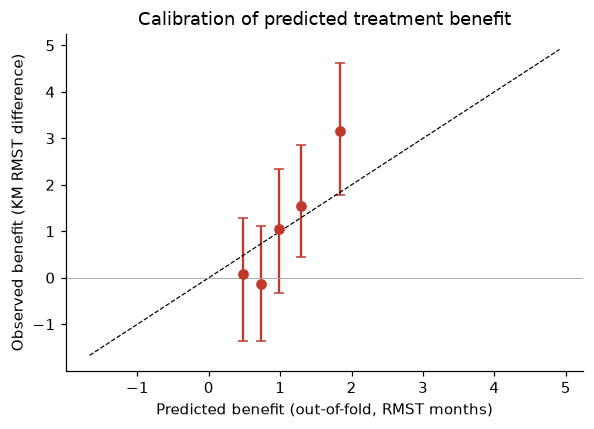

Everyone sunitinib: 7.98 months | Everyone avelumab+axitinib: 8.77 months
share sent to sunitinib  expected_RMST12  gain_vs_treat_all_combination  lo95  hi95
                     0%             8.77                           0.00  0.00  0.00
                    10%             8.56                          -0.20 -0.68  0.26
                    20%             8.64                          -0.13 -0.75  0.54
                    30%             8.55                          -0.22 -0.96  0.61
                    40%             8.39                          -0.37 -1.24  0.58
                    50%             8.57                          -0.20 -1.16  0.88

How to read this: forest CATEs are shrunk toward the average, so no patient is predicted to do worse on the combination (a 'treat if CATE>0' rule would equal treat-all). Moving the lowest-ranked patients to sunitinib does NOT improve expected PFS (all CIs include 0, point estimates are negative). The lowest quintiles show roughly *no b

In [12]:
import statsmodels.api as sm

def blp_test(Y, tau_hat):
    m = cross_val_predict(GradientBoostingRegressor(n_estimators=100, max_depth=2, learning_rate=0.05, subsample=0.7, random_state=SEED),
                          np.c_[T, Xv], Y, cv=KFold(5, shuffle=True, random_state=SEED))
    score = (T - 0.5) / 0.25 * (Y - m)                 # mean = true CATE because P(T=1)=0.5
    fit = sm.OLS(score, sm.add_constant(np.c_[tau_hat])).fit(cov_type="HC3")
    return fit.params[1], fit.conf_int()[1], fit.pvalues[1]

for tag, Y in [("rmst", Y_rmst), ("s12", Y_s12)]:
    b, ci, p = blp_test(Y, cate_oof[tag])
    print(f"[{tag}] calibration slope = {b:.2f} (95% CI {ci[0]:.2f} to {ci[1]:.2f}), p = {p:.3f}")

tau = cate_oof["rmst"]
q = pd.qcut(tau, 5, labels=False)
rows = []
for k in range(5):
    m = q == k
    est, ci = boot_diff(time_[m], event[m], T[m], "rmst", B=300, seed=k)
    rows.append((k + 1, tau[m].mean(), est, ci[0], ci[1], m.sum()))
qdf = pd.DataFrame(rows, columns=["quintile", "predicted_CATE", "observed_RMST_diff", "lo", "hi", "n"])
print(qdf.round(2).to_string(index=False))

fig, ax = plt.subplots(figsize=(5.5, 4))
ax.errorbar(qdf.predicted_CATE, qdf.observed_RMST_diff, yerr=[qdf.observed_RMST_diff - qdf.lo, qdf.hi - qdf.observed_RMST_diff], fmt="o", color="#c0392b", capsize=3)
lim = [min(qdf.lo.min(), qdf.predicted_CATE.min()) - .3, max(qdf.hi.max(), qdf.predicted_CATE.max()) + .3]
ax.plot(lim, lim, "k--", lw=.8); ax.axhline(0, color="#aaa", lw=.6)
ax.set_xlabel("Predicted benefit (out-of-fold, RMST months)"); ax.set_ylabel("Observed benefit (KM RMST difference)")
ax.set_title("Calibration of predicted treatment benefit"); plt.tight_layout(); plt.show()

# Policy curve: send the f% of patients with the LOWEST predicted benefit to sunitinib, everyone else gets the combination.
# Value = expected RMST(12m), estimated by inverse-probability weighting (known randomisation prob 0.5; pseudo-observations handle censoring).
Y = Y_rmst
def policy_value_idx(Y, T, send_sun):
    arm = np.where(send_sun, 0, 1)
    return np.mean(Y * (T == arm) / 0.5)

order = np.argsort(tau)
rows = []
rng = np.random.default_rng(1)
boots = [rng.integers(0, len(Y), len(Y)) for _ in range(500)]
for f in [0, 0.1, 0.2, 0.3, 0.4, 0.5]:
    send = np.zeros(len(Y), bool); send[order[: int(f * len(Y))]] = True
    v = policy_value_idx(Y, T, send)
    d = [policy_value_idx(Y[b], T[b], send[b]) - policy_value_idx(Y[b], T[b], np.zeros(len(b), bool)) for b in boots]
    rows.append((f"{int(f*100)}%", v, v - policy_value_idx(Y, T, np.zeros(len(Y), bool)), *np.percentile(d, [2.5, 97.5])))
pol = pd.DataFrame(rows, columns=["share sent to sunitinib", "expected_RMST12", "gain_vs_treat_all_combination", "lo95", "hi95"])
print("Everyone sunitinib: %.2f months | Everyone avelumab+axitinib: %.2f months" % (
    policy_value_idx(Y, T, np.ones(len(Y), bool)), policy_value_idx(Y, T, np.zeros(len(Y), bool))))
print(pol.round(2).to_string(index=False))
print("\nHow to read this: forest CATEs are shrunk toward the average, so no patient is predicted to do worse on the combination "
      "(a 'treat if CATE>0' rule would equal treat-all). Moving the lowest-ranked patients to sunitinib does NOT improve expected PFS "
      "(all CIs include 0, point estimates are negative). The lowest quintiles show roughly *no benefit* from the combination, not evidence of harm.")

# 8. Drivers
We separate two different things:
* **Prognostic drivers** — predict outcome regardless of drug
* **Predictive drivers (effect modifiers)** — change *how much the combination beats sunitinib*. These are the causal "who should get what" drivers

## Predictive drivers: arm × biomarker interaction (Cox), BH-FDR across all features

In [13]:
from statsmodels.stats.multitest import multipletests
from scipy import stats

def prep_feature(x):
    """0/1 features stay as is; continuous ones are rank-normalised (robust to skew/outliers, e.g. lipid score)."""
    x = np.asarray(x, float)
    if set(np.unique(x)) <= {0.0, 1.0}:
        return x
    return stats.norm.ppf((stats.rankdata(x) - 0.5) / len(x))

base = pd.DataFrame({"time": time_, "event": event, "T": T, "age": F.age.values, "male": F.male.values}, index=X.index)
rows = []
for c in feat_names:
    if c in ("age", "male"): continue
    z = prep_feature(X[c].values)
    binary = set(np.unique(z)) <= {0.0, 1.0}
    d = base.assign(x=z, Tx=z * T)
    try:
        f = CoxPHFitter(penalizer=0.01).fit(d, "time", "event")
        s = f.summary
        rows.append((c, binary, s.loc["Tx", "exp(coef)"], s.loc["Tx", "p"], s.loc["x", "exp(coef)"], s.loc["x", "p"], s.loc["T", "exp(coef)"]))
    except Exception:
        pass
inter = pd.DataFrame(rows, columns=["feature", "binary", "HR_interaction", "p_interaction", "HR_main(sunitinib arm)", "p_main", "HR_T_at_x0"])
inter["q_interaction"] = multipletests(inter.p_interaction, method="fdr_bh")[1]
inter = inter.sort_values("p_interaction")
print("Features tested:", len(inter), "| q<0.10:", (inter.q_interaction < 0.10).sum(), "| nominal p<0.05:", (inter.p_interaction < 0.05).sum(),
      "(expected by chance ~%.0f)" % (0.05 * len(inter)))
print(inter.head(15)[["feature", "HR_interaction", "p_interaction", "q_interaction"]].round(4).to_string(index=False))
print("\nHR_interaction < 1 => benefit of avelumab+axitinib over sunitinib is LARGER when the feature is higher (per 1 SD of the rank-normalised score for continuous features).")

Features tested: 129 | q<0.10: 14 | nominal p<0.05: 17 (expected by chance ~6)
                                         feature  HR_interaction  p_interaction  q_interaction
           path_B9991003_rc5_Cell_cell_signaling          1.7422         0.0000         0.0000
                                       expr_FLT1          1.4893         0.0002         0.0126
                                        expr_KDR          1.4742         0.0003         0.0131
                  path_B9991003_rc3_Angiogenesis          1.4420         0.0005         0.0174
                            path_MCDERMOTT_ANGIO          1.4292         0.0009         0.0236
path_B9991003_rc2_Organic_acid_metabolic_process          1.4334         0.0012         0.0249
 path_B9991003_c22_Morphogenesis_Homeobox_gene_c          1.3888         0.0015         0.0274
                   path_B9991003_c3_Angiogenesis          1.3864         0.0018         0.0295
 path_B9991003_c2_Organic_acid_metabolic_process          1.4001  

## Predictive drivers from the causal forest (what the CATE model actually uses)

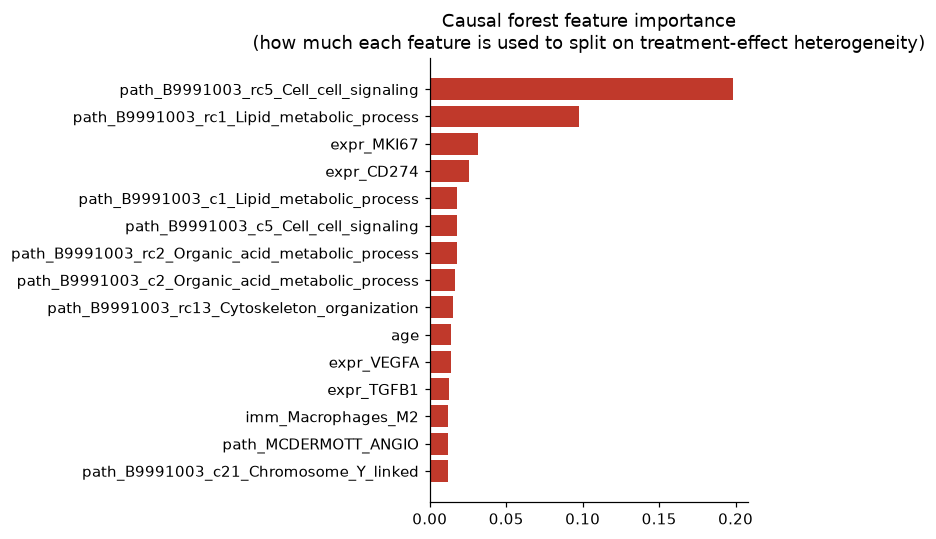

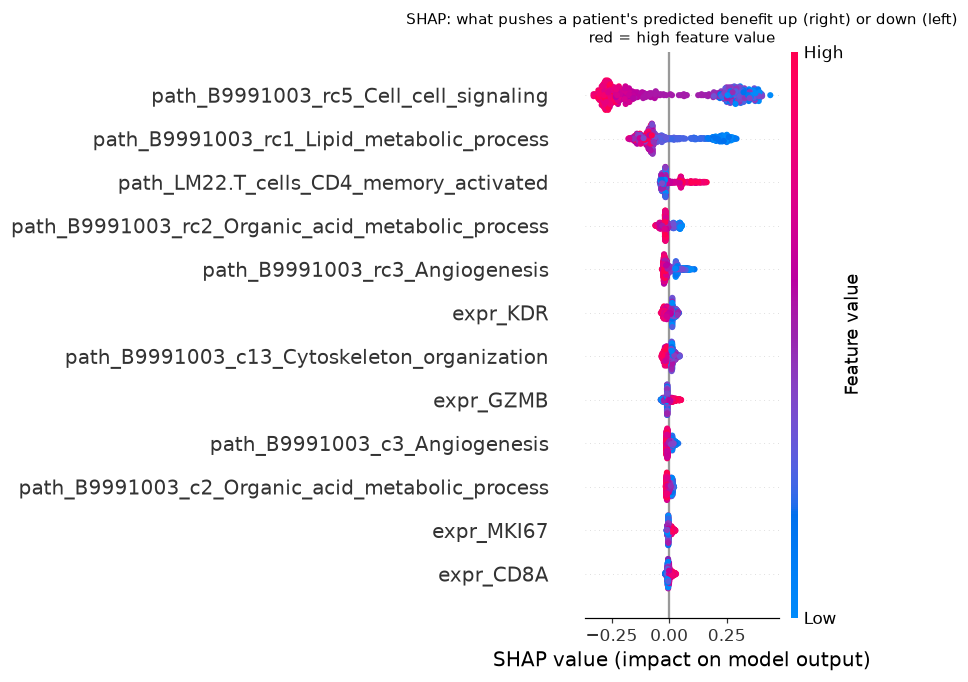

                                                  forest_importance  \
path_B9991003_rc5_Cell_cell_signaling                        0.1982   
path_B9991003_rc1_Lipid_metabolic_process                    0.0976   
expr_MKI67                                                   0.0318   
expr_CD274                                                   0.0256   
path_B9991003_c1_Lipid_metabolic_process                     0.0181   
path_B9991003_c5_Cell_cell_signaling                         0.0177   
path_B9991003_rc2_Organic_acid_metabolic_process             0.0177   
path_B9991003_c2_Organic_acid_metabolic_process              0.0166   
path_B9991003_rc13_Cytoskeleton_organization                 0.0149   
age                                                          0.0141   
expr_VEGFA                                                   0.0136   
expr_TGFB1                                                   0.0126   

                                                  shap_importance  \
path_B9

In [14]:
cf_full = make_cf().fit(Y_rmst, T, X=Xv)
imp = pd.Series(cf_full.feature_importances_, index=feat_names).sort_values(ascending=False)

# SHAP on a surrogate model of the out-of-fold CATE gives direction as well as size
import shap
from sklearn.ensemble import RandomForestRegressor
sur = RandomForestRegressor(n_estimators=400, min_samples_leaf=10, random_state=SEED, n_jobs=-1).fit(Xv, cate_oof["rmst"])
sv = shap.TreeExplainer(sur).shap_values(Xv)
shap_imp = pd.Series(np.abs(sv).mean(0), index=feat_names).sort_values(ascending=False)

top = imp.head(15)[::-1]
fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(top.index, top.values, color="#c0392b"); ax.set_title("Causal forest feature importance\n(how much each feature is used to split on treatment-effect heterogeneity)")
plt.tight_layout(); plt.show()

shap.summary_plot(sv, X, max_display=12, show=False)
plt.title("SHAP: what pushes a patient's predicted benefit up (right) or down (left)\nred = high feature value", fontsize=10)
plt.tight_layout(); plt.show()

both = pd.concat([imp.rename("forest_importance"), shap_imp.rename("shap_importance")], axis=1)
both["rank_forest"] = both.forest_importance.rank(ascending=False); both["rank_shap"] = both.shap_importance.rank(ascending=False)
both = both.join(inter.set_index("feature")[["HR_interaction", "p_interaction", "q_interaction"]])
print(both.sort_values("forest_importance", ascending=False).head(12).round(4))

## Prognostic drivers (outcome regardless of drug) — univariable Cox adjusted for arm, age, sex

q<0.10: 23 of 129


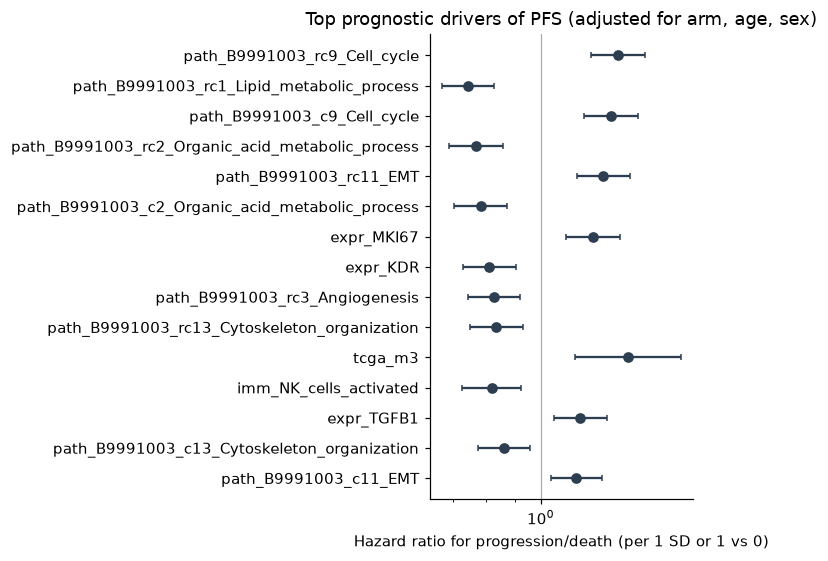

                                         feature     HR     lo     hi      p      q
                    path_B9991003_rc9_Cell_cycle 1.3679 1.2258 1.5266 0.0000 0.0000
       path_B9991003_rc1_Lipid_metabolic_process 0.7443 0.6694 0.8275 0.0000 0.0000
                     path_B9991003_c9_Cell_cycle 1.3325 1.1938 1.4873 0.0000 0.0000
path_B9991003_rc2_Organic_acid_metabolic_process 0.7699 0.6902 0.8588 0.0000 0.0001
                          path_B9991003_rc11_EMT 1.2899 1.1585 1.4361 0.0000 0.0001
 path_B9991003_c2_Organic_acid_metabolic_process 0.7841 0.7044 0.8729 0.0000 0.0002
                                      expr_MKI67 1.2371 1.1094 1.3794 0.0001 0.0024
                                        expr_KDR 0.8123 0.7289 0.9054 0.0002 0.0028
                  path_B9991003_rc3_Angiogenesis 0.8292 0.7459 0.9218 0.0005 0.0076
    path_B9991003_rc13_Cytoskeleton_organization 0.8353 0.7500 0.9303 0.0011 0.0135
                                         tcga_m3 1.4277 1.1515 1.7701 0.0012

In [15]:
rows = []
for c in feat_names:
    if c in ("age", "male"): continue
    z = prep_feature(X[c].values)
    try:
        f = CoxPHFitter(penalizer=0.01).fit(base.assign(x=z).drop(columns=[]), "time", "event")
        s = f.summary.loc["x"]
        rows.append((c, s["exp(coef)"], s["exp(coef) lower 95%"], s["exp(coef) upper 95%"], s["p"]))
    except Exception:
        pass
prog = pd.DataFrame(rows, columns=["feature", "HR", "lo", "hi", "p"])
prog["q"] = multipletests(prog.p, method="fdr_bh")[1]
prog = prog.sort_values("p")
print("q<0.10:", (prog.q < 0.10).sum(), "of", len(prog))
topp = prog.head(15).iloc[::-1]
fig, ax = plt.subplots(figsize=(6.5, 5.2))
ax.errorbar(topp.HR, range(len(topp)), xerr=[topp.HR - topp.lo, topp.hi - topp.HR], fmt="o", color="#2c3e50", capsize=2)
ax.axvline(1, color="#aaa", lw=.8); ax.set_yticks(range(len(topp))); ax.set_yticklabels(topp.feature); ax.set_xscale("log")
ax.set_xlabel("Hazard ratio for progression/death (per 1 SD or 1 vs 0)"); ax.set_title("Top prognostic drivers of PFS (adjusted for arm, age, sex)")
plt.tight_layout(); plt.show()
print(prog.head(15).round(4).to_string(index=False))

## What do the top predictive drivers look like? Effect of the combination by biomarker tertile

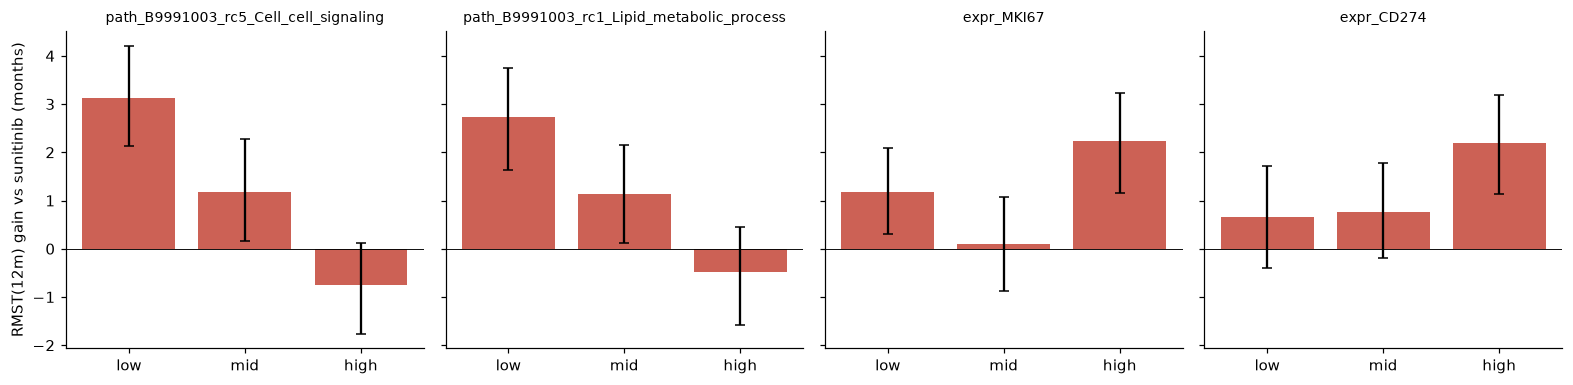

In [16]:
top_drivers = [f for f in imp.index if f not in ("age", "male")][:4]
fig, axes = plt.subplots(1, len(top_drivers), figsize=(3.6 * len(top_drivers), 3.6), sharey=True)
for ax, f in zip(np.atleast_1d(axes), top_drivers):
    x = X[f].values
    if set(np.unique(x)) <= {0.0, 1.0}:
        grp, labs = x.astype(int), ["0", "1"]
    else:
        grp, labs = pd.qcut(x, 3, labels=False, duplicates="drop"), ["low", "mid", "high"]
    out = []
    for g in np.unique(grp):
        m = grp == g
        est, ci = boot_diff(time_[m], event[m], T[m], "rmst", B=300, seed=g)
        out.append((est, ci))
    ests = [o[0] for o in out]; los = [o[0] - o[1][0] for o in out]; his = [o[1][1] - o[0] for o in out]
    ax.bar(range(len(ests)), ests, yerr=[los, his], color="#c0392b", alpha=.8, capsize=3)
    ax.set_xticks(range(len(ests))); ax.set_xticklabels(labs[:len(ests)]); ax.axhline(0, color="k", lw=.6); ax.set_title(f, fontsize=9)
np.atleast_1d(axes)[0].set_ylabel("RMST(12m) gain vs sunitinib (months)")
plt.tight_layout(); plt.show()

# 9. Individual counterfactual predictions
For any patient, predict PFS under **both** arms (Random Survival Forest) and the personalised benefit (causal forest, with uncertainty)

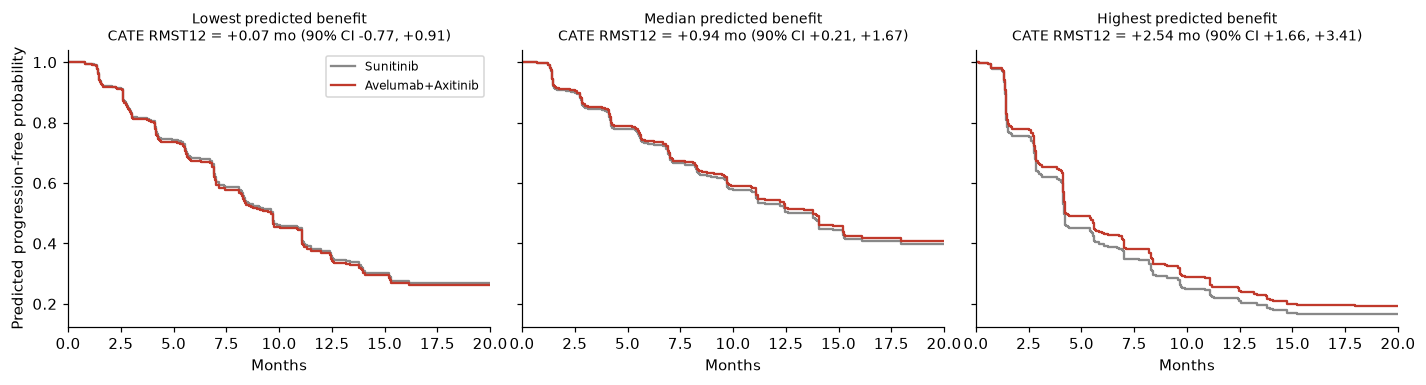

Saved: patient_level_predictions.csv, predictive_drivers_interaction_tests.csv, prognostic_drivers.csv, causal_forest_importance.csv


,arm,pred_RMST12_gain_months,oof_RMST12_gain_months,oof_PFS12_prob_gain,recommended_arm
id,,,,,
X00936b9285d6b8665ae9122993fb8e91,Avelumab+Axitinib,0.291461,0.646125,0.096883,Avelumab+Axitinib
X105622fadc33f23755ac2df823110aca,Sunitinib,1.059047,0.818707,0.062844,Avelumab+Axitinib
Xe44f39747a8e84b02b4cb24659312144,Sunitinib,0.343078,0.386325,0.095624,Avelumab+Axitinib
X293dd1284496215e9a0eca9f17a98e7e,Sunitinib,0.387061,0.484719,0.156706,Avelumab+Axitinib
X01ed7190ce00862696edbf047b542045,Sunitinib,0.306142,0.567510,0.100513,Avelumab+Axitinib


In [17]:
rsf = RandomSurvivalForest(n_estimators=500, min_samples_leaf=15, max_features="sqrt", n_jobs=-1, random_state=SEED).fit(XD, y_surv)

def predict_patient(i, ax=None):
    """i = row position in the cohort. Returns predicted S(t) under each arm + CATE."""
    x = X.values[i:i + 1]
    s_sun = rsf.predict_survival_function(np.c_[[0], x])[0]
    s_aa  = rsf.predict_survival_function(np.c_[[1], x])[0]
    cate = cf_full.effect(x).ravel()[0]
    lo, hi = cf_full.effect_interval(x, alpha=0.1)
    return s_sun, s_aa, cate, float(lo.ravel()[0]), float(hi.ravel()[0])

tau_all = cf_full.effect(Xv).ravel()
order = np.argsort(tau_all)
picks = [order[0], order[len(order) // 2], order[-1]]
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6), sharey=True)
for ax, i, title in zip(axes, picks, ["Lowest predicted benefit", "Median predicted benefit", "Highest predicted benefit"]):
    s_sun, s_aa, c, lo, hi = predict_patient(i)
    ax.step(s_sun.x, s_sun.y, where="post", color="#888", label="Sunitinib")
    ax.step(s_aa.x, s_aa.y, where="post", color="#c0392b", label="Avelumab+Axitinib")
    ax.set_xlim(0, 20); ax.set_title(f"{title}\nCATE RMST12 = {c:+.2f} mo (90% CI {lo:+.2f}, {hi:+.2f})", fontsize=9); ax.set_xlabel("Months")
axes[0].set_ylabel("Predicted progression-free probability"); axes[0].legend(fontsize=8)
plt.tight_layout(); plt.show()

# table for every patient (export-ready)
pred = pd.DataFrame({
    "id": X.index, "arm": clin_c.TRT01P.values,
    "pred_RMST12_gain_months": tau_all,
    "oof_RMST12_gain_months": cate_oof["rmst"],
    "oof_PFS12_prob_gain": cate_oof["s12"],
    "recommended_arm": np.where(cate_oof["rmst"] > 0, "Avelumab+Axitinib", "Sunitinib"),
}).set_index("id")
pred.to_csv("patient_level_predictions.csv")
inter.to_csv("predictive_drivers_interaction_tests.csv", index=False)
prog.to_csv("prognostic_drivers.csv", index=False)
both.sort_values("forest_importance", ascending=False).to_csv("causal_forest_importance.csv")
print("Saved: patient_level_predictions.csv, predictive_drivers_interaction_tests.csv, prognostic_drivers.csv, causal_forest_importance.csv")
pred.head()